In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.gofplots import qqplot

# Set style for plots
sns.set_style("whitegrid")

# Import the dataset
df = pd.read_csv('dataset.csv')
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,1
1186,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,1
1187,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1
1188,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1


In [12]:
# ======================================================================
# 0. Basic Dataset Information
# ======================================================================
print("=== BASIC DATASET INFORMATION ===")
print(f"\nNumber of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print("\nColumn list:")
print(df.columns.tolist())



=== BASIC DATASET INFORMATION ===

Number of rows: 1190
Number of columns: 12

Column list:
['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']


In [14]:
# ======================================================================
# 1. Feature Classification
# ======================================================================
numeric_cols = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
categorical_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 
                   'exercise angina', 'ST slope', 'target']

print("\n=== FEATURE TYPES ===")
print(f"\nNumeric Features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")




=== FEATURE TYPES ===

Numeric Features (5): ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
Categorical Features (7): ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope', 'target']


In [16]:
# ======================================================================
# 2. Unique Values Analysis
# ======================================================================
print("\n=== UNIQUE VALUES PER COLUMN ===")
for col in df.columns:
    unique_vals = np.sort(df[col].dropna().unique())
    print(f"\n{col} ({df[col].dtype}): {len(unique_vals)} unique values")
    if len(unique_vals) <= 20:  # Only show all values if there are few
        print(unique_vals)
    else:
        print(f"Range: {unique_vals[0]} to {unique_vals[-1]}")




=== UNIQUE VALUES PER COLUMN ===

age (float64): 50 unique values
Range: 28.0 to 77.0

sex (float64): 2 unique values
[0. 1.]

chest pain type (float64): 4 unique values
[1. 2. 3. 4.]

resting bp s (float64): 66 unique values
Range: 0.0 to 200.0

cholesterol (float64): 222 unique values
Range: 0.0 to 603.0

fasting blood sugar (float64): 2 unique values
[0. 1.]

resting ecg (float64): 3 unique values
[0. 1. 2.]

max heart rate (float64): 119 unique values
Range: 60.0 to 202.0

exercise angina (float64): 2 unique values
[0. 1.]

oldpeak (float64): 53 unique values
Range: -2.6 to 6.2

ST slope (float64): 4 unique values
[0. 1. 2. 3.]

target (int64): 2 unique values
[0 1]


In [18]:
# ======================================================================
# 3. Handle Missing Values
# ======================================================================
print("\n=== MISSING VALUES ===")
print("\nBefore handling:")
print(df.isnull().sum())

for col in df.columns:
    if col in numeric_cols:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nAfter handling:")
print(df.isnull().sum())




=== MISSING VALUES ===

Before handling:
age                    3
sex                    2
chest pain type        1
resting bp s           7
cholesterol            2
fasting blood sugar    1
resting ecg            4
max heart rate         3
exercise angina        1
oldpeak                1
ST slope               1
target                 0
dtype: int64

After handling:
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64


/var/folders/z4/25skdbmd0957wzbcsmcw4gc40000gn/T/ipykernel_92722/504650843.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/z4/25skdbmd0957wzbcsmcw4gc40000gn/T/ipykernel_92722/504650843.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always


=== DATA DISTRIBUTIONS ===

Numeric Features Distribution:


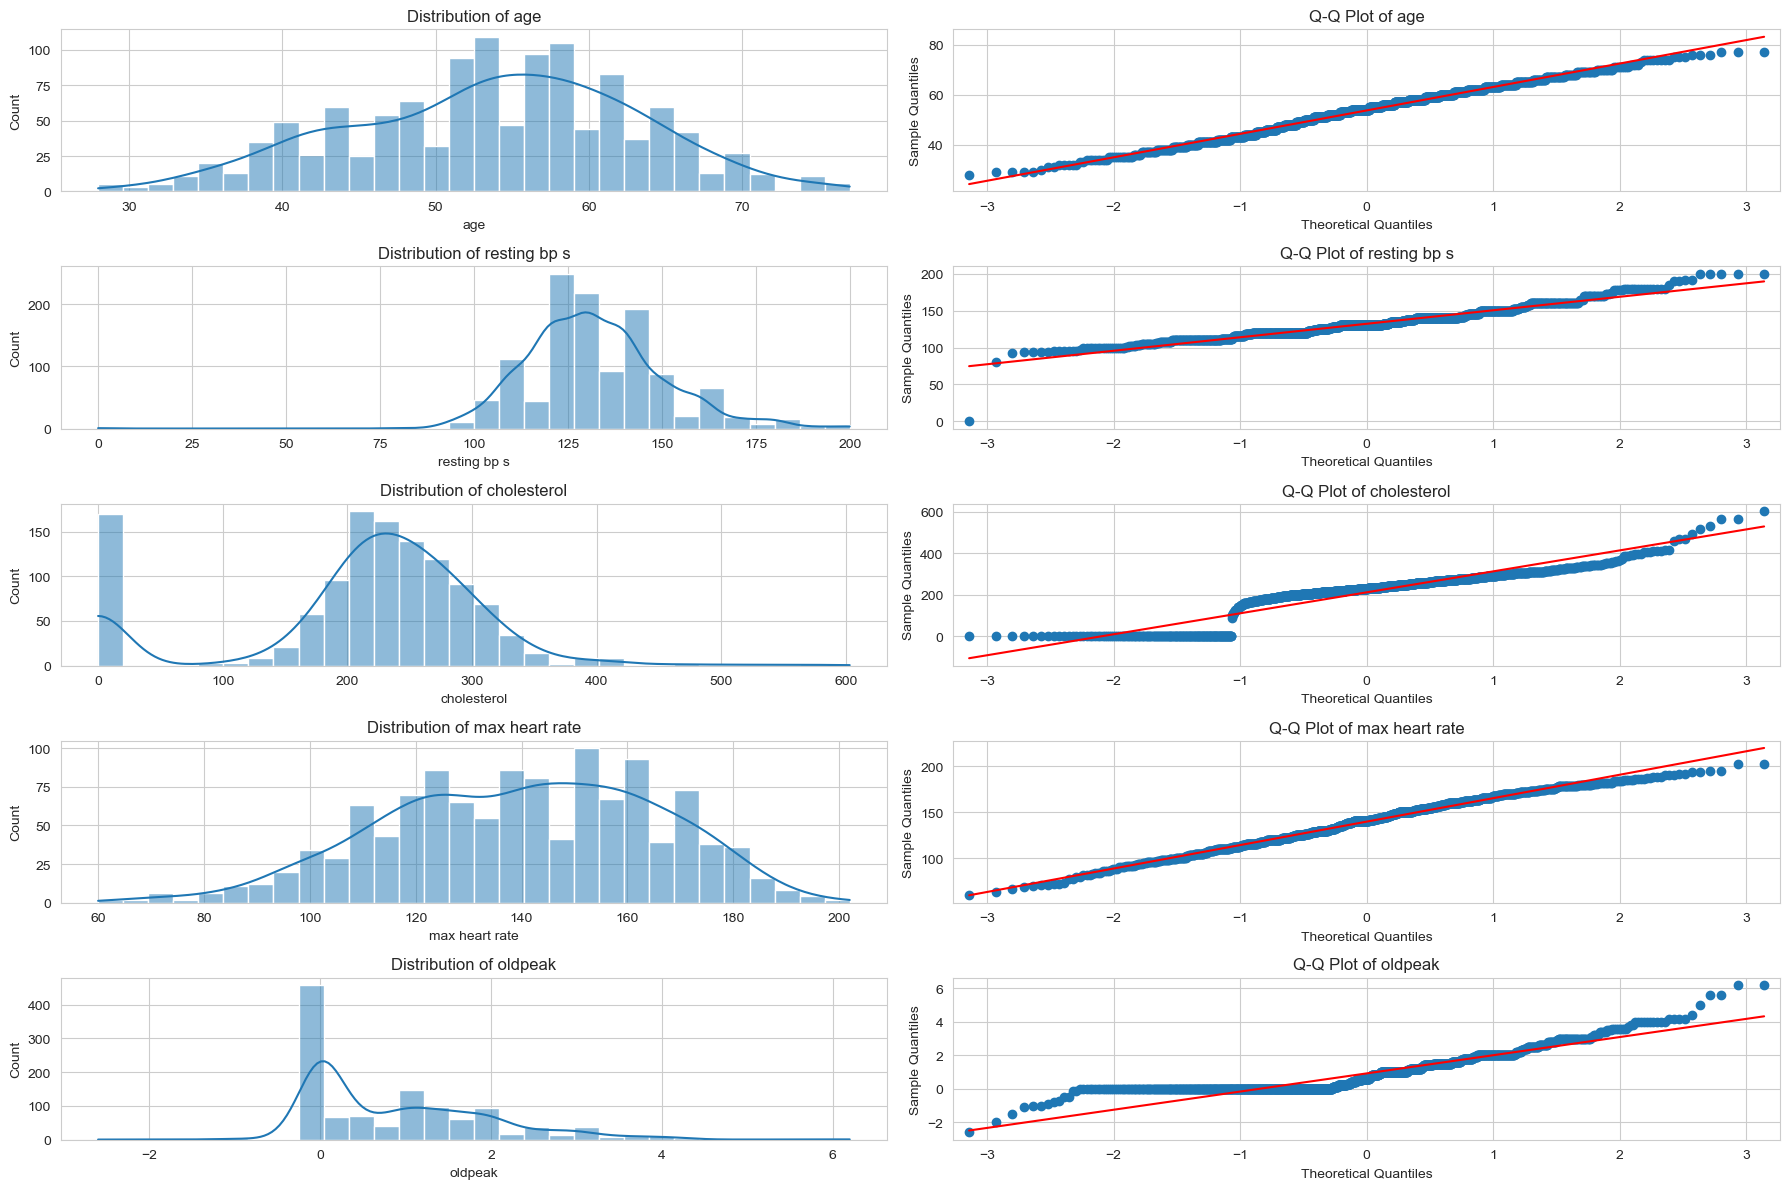


Categorical Features Distribution:


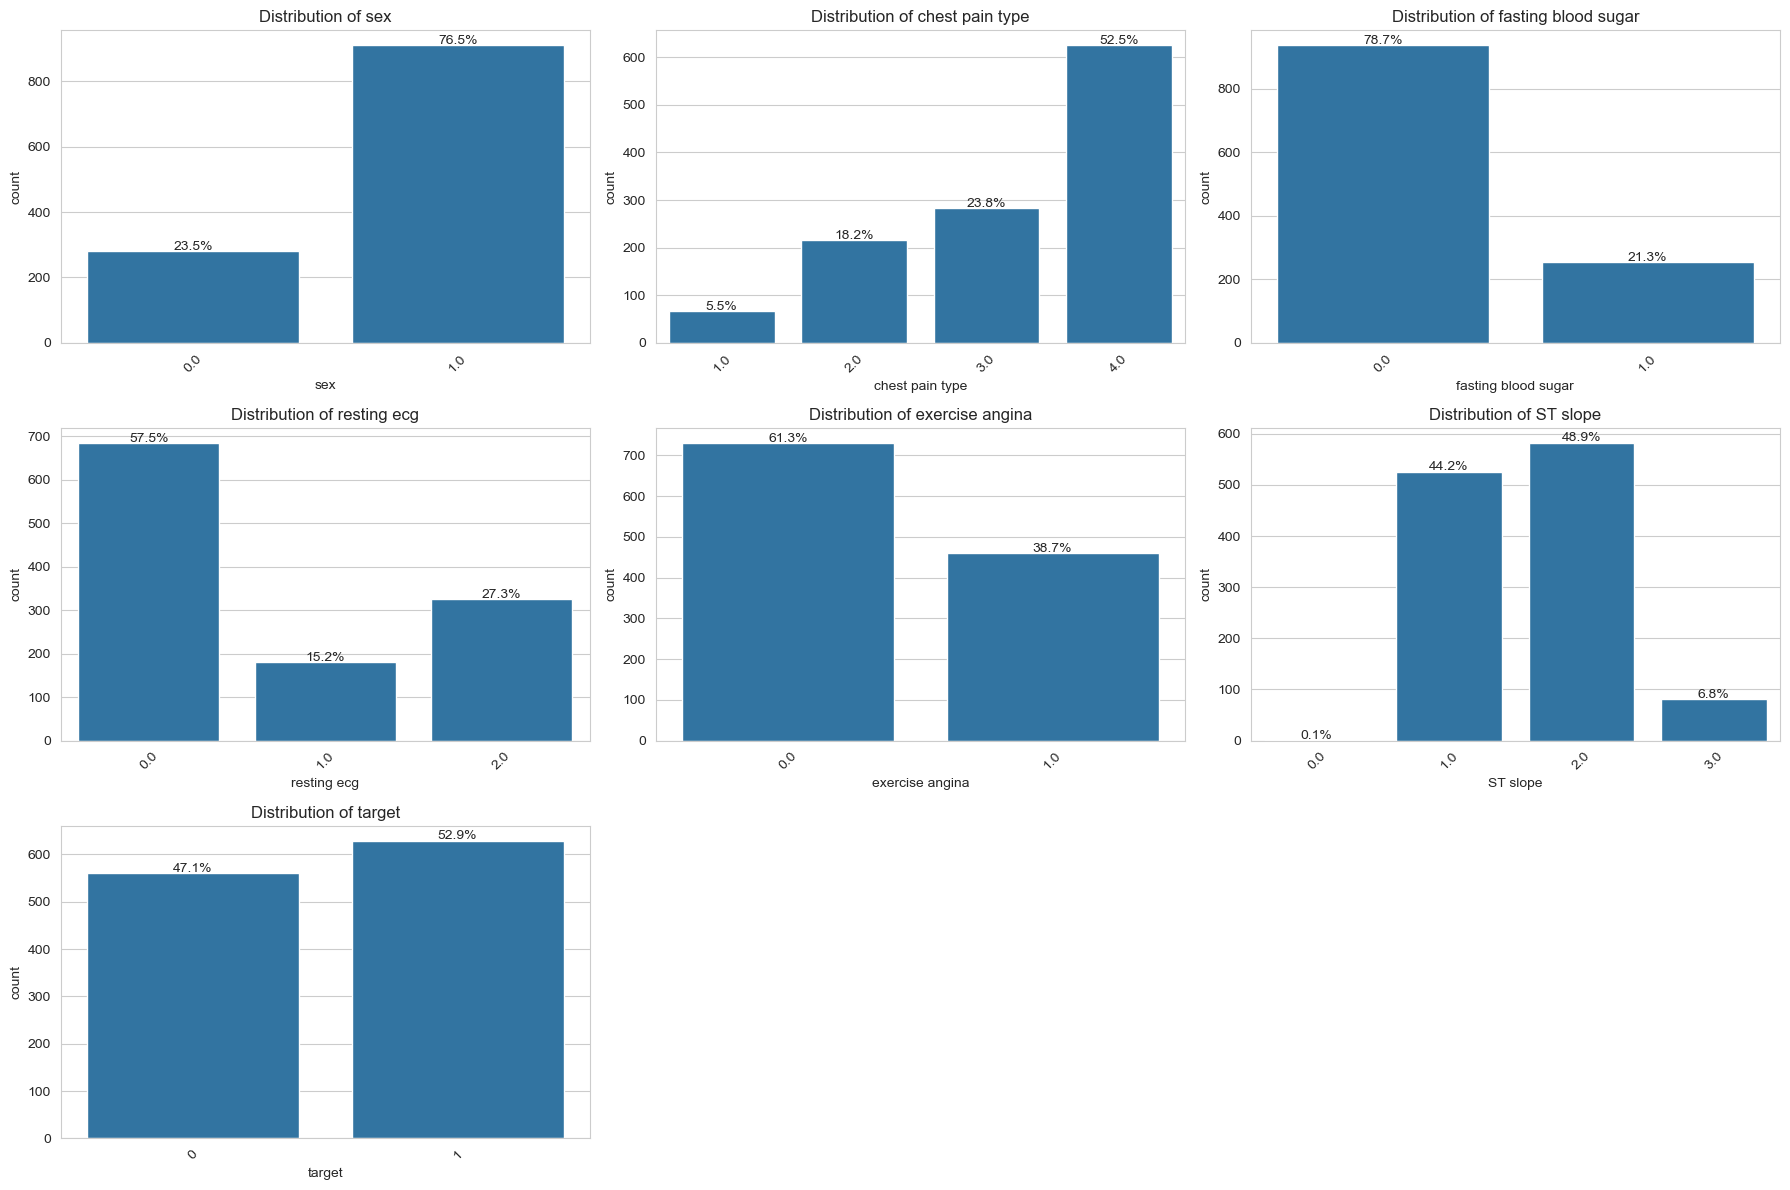

In [20]:
# ======================================================================
# 4. Data Distribution Visualization
# ======================================================================
print("\n=== DATA DISTRIBUTIONS ===")

# Numeric Features - Distribution and Normality
print("\nNumeric Features Distribution:")
plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols, 1):
    # Histogram with KDE
    plt.subplot(len(numeric_cols), 2, 2*i-1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    
    # Q-Q Plot for normality check
    plt.subplot(len(numeric_cols), 2, 2*i)
    qqplot(df[col], line='s', ax=plt.gca())
    plt.title(f'Q-Q Plot of {col}')
plt.tight_layout()
plt.show()

# Categorical Features - Count Plots
print("\nCategorical Features Distribution:")
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    ax = sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    
    # Add percentage labels
    total = len(df[col])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2., height + 3,
                f'{height/total:.1%}', ha='center')
plt.tight_layout()
plt.show()




Plotting probability distributions...


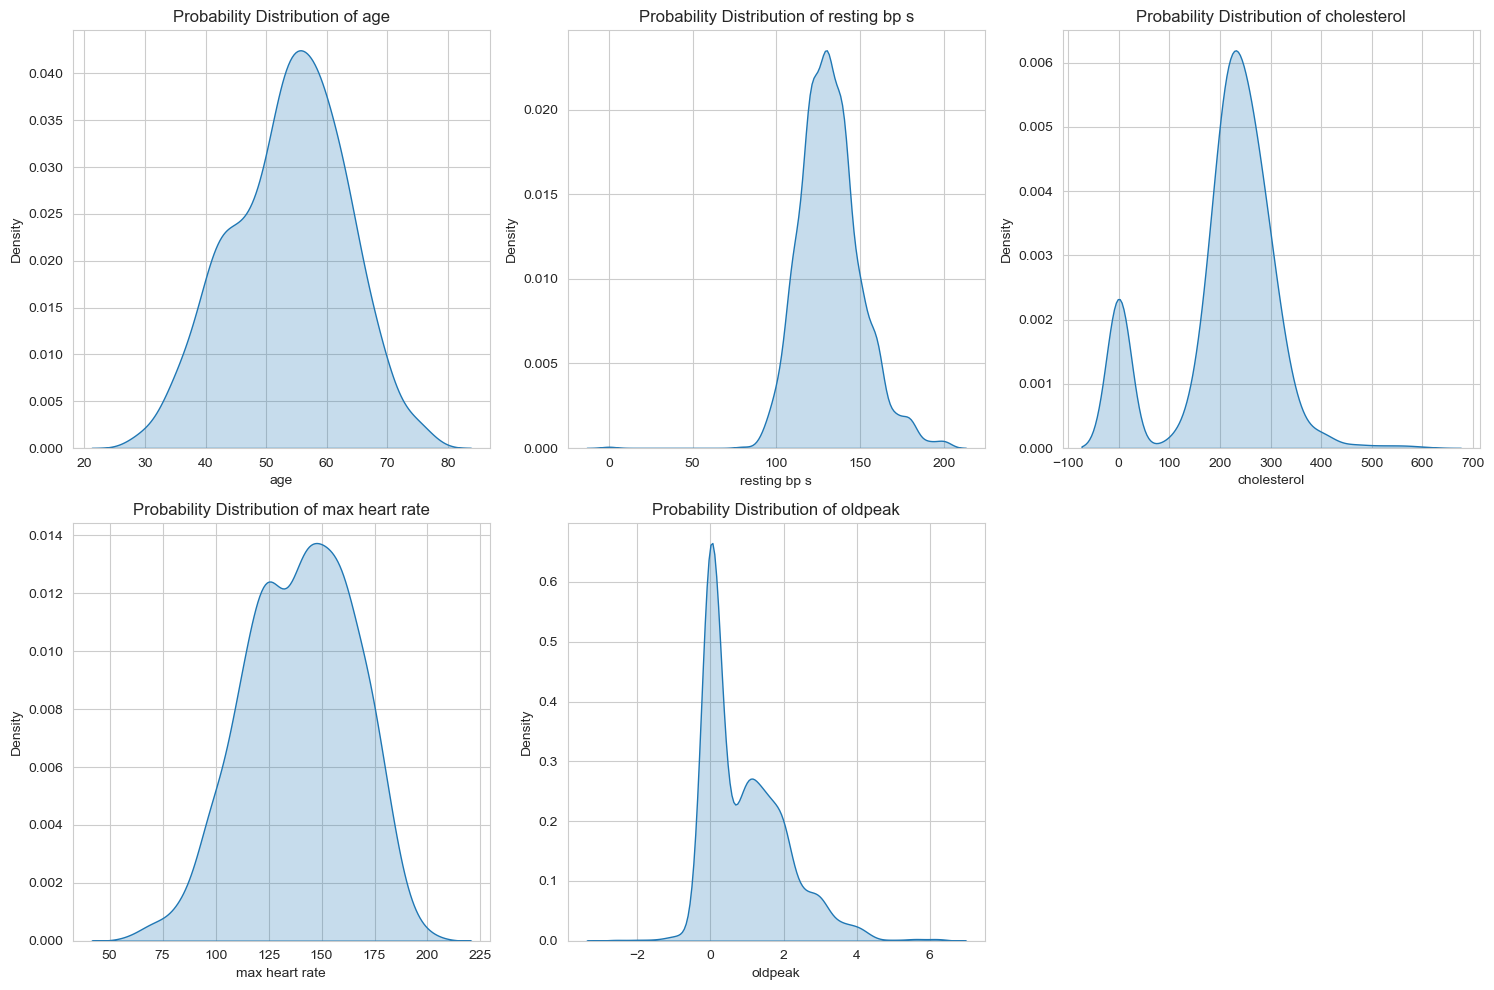

In [22]:
# ======================================================================
# 5. Probability Distribution for numerical columns
# ======================================================================
print("\nPlotting probability distributions...")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Probability Distribution of {col}')
plt.tight_layout()
plt.show()



=== OUTLIER ANALYSIS ===

Boxplots Before Outlier Handling:


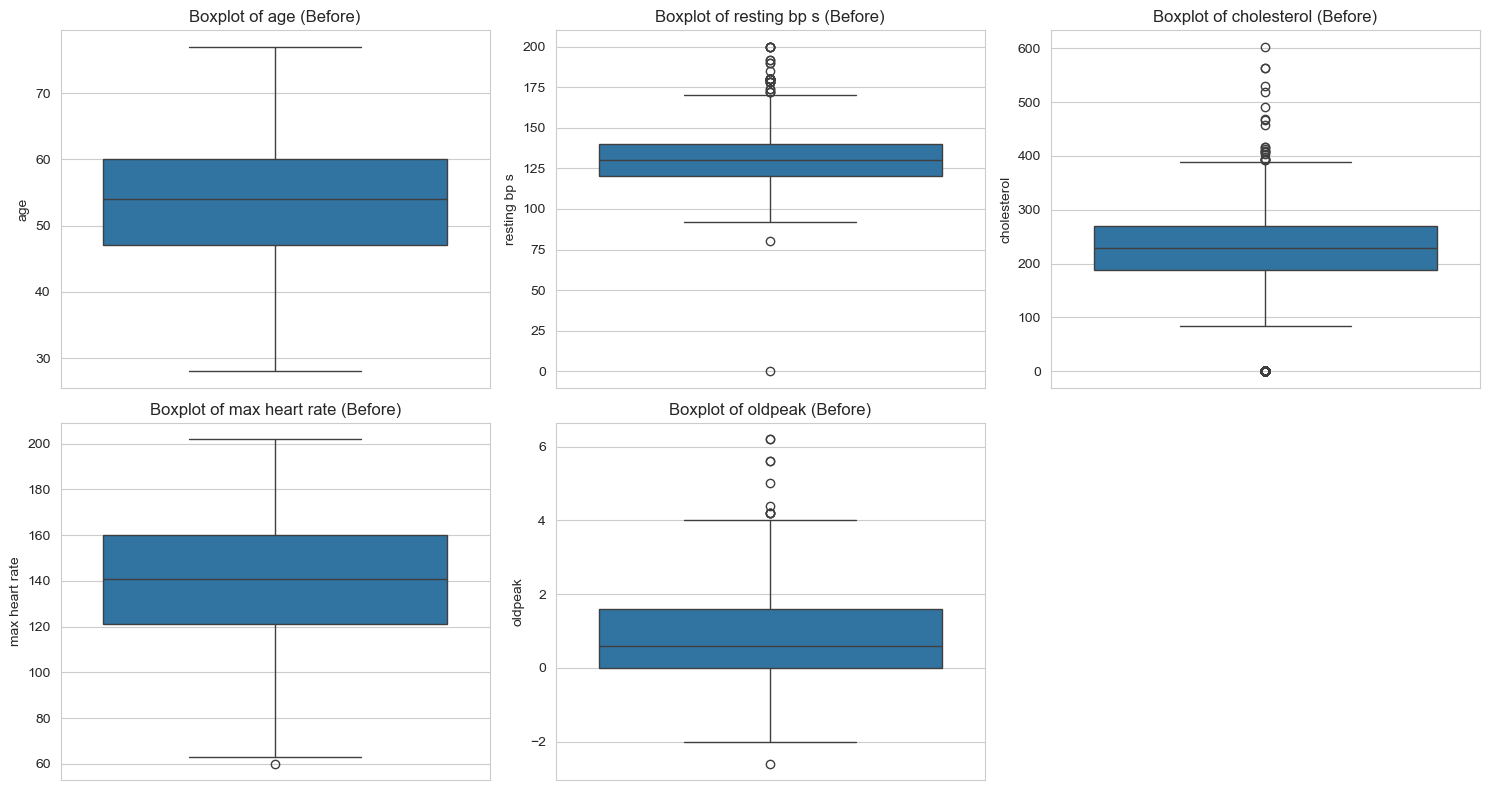


--- age ---
Skewness: -0.19
Using Z-score method (near-normal data)
Outliers detected: 0
Median before: N/A
Median after: 54.0

--- resting bp s ---
Skewness: 0.30
Using Z-score method (near-normal data)
Outliers detected: 10
Median before: 196.0
Median after: 130.0

--- cholesterol ---
Skewness: -0.79
Using Z-score method (near-normal data)
Outliers detected: 5
Median before: 564.0
Median after: 229.0

--- max heart rate ---
Skewness: -0.24
Using Z-score method (near-normal data)
Outliers detected: 2
Median before: 61.5
Median after: 141.0

--- oldpeak ---
Skewness: 1.10
Using IQR method (skewed data)
Outliers detected: 11
Median before: 4.4
Median after: 0.6

Boxplots After Outlier Handling:


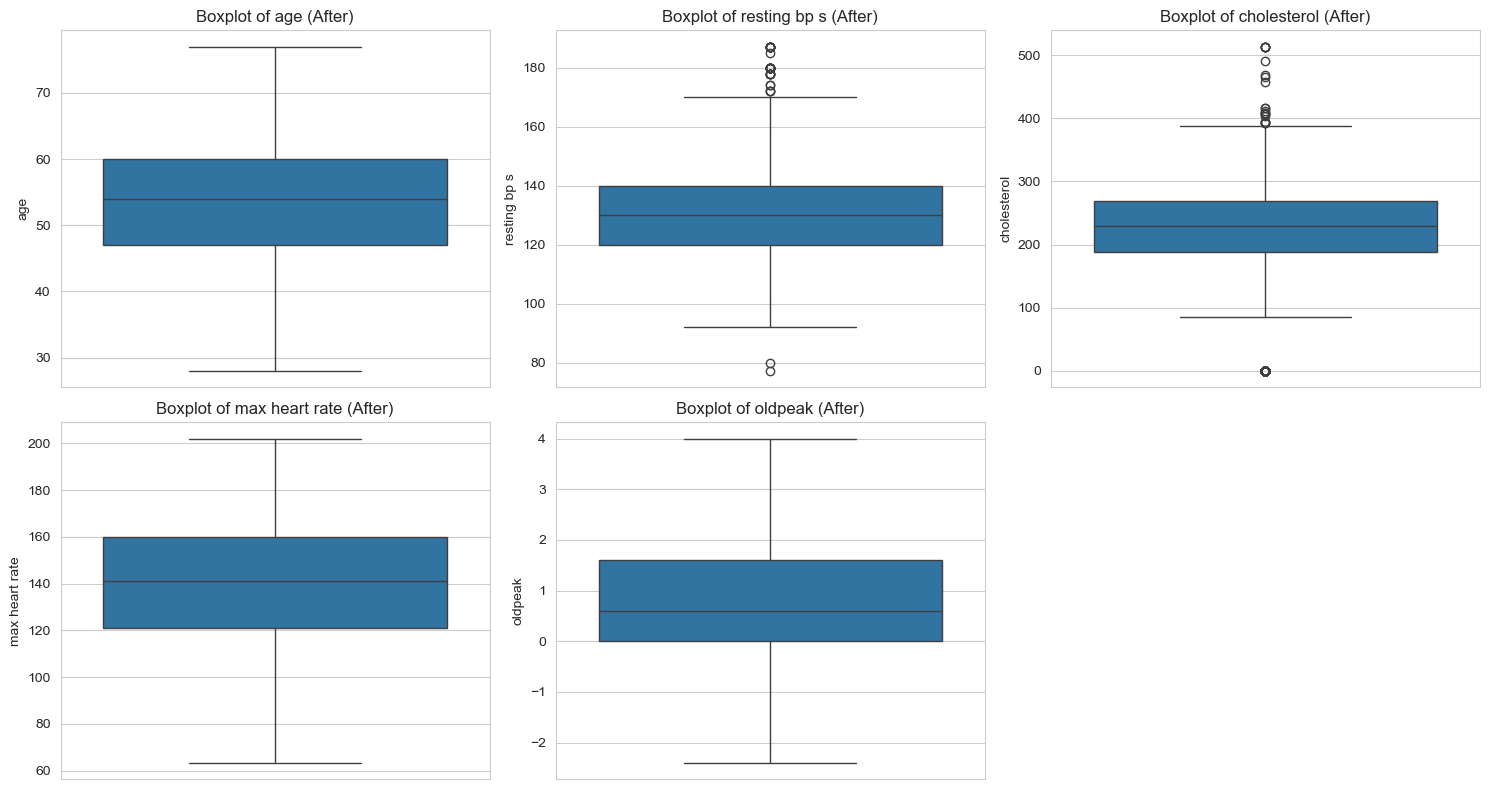


=== FINAL DATASET SUMMARY ===

Dataset dimensions: 1190 rows × 12 columns

Column list with data types:
age                    float64
sex                    float64
chest pain type        float64
resting bp s           float64
cholesterol            float64
fasting blood sugar    float64
resting ecg            float64
max heart rate         float64
exercise angina        float64
oldpeak                float64
ST slope               float64
target                   int64
dtype: object

Descriptive Statistics:
               age  resting bp s  cholesterol  max heart rate      oldpeak
count  1190.000000   1190.000000  1190.000000     1190.000000  1190.000000
mean     53.717647    132.198956   210.573587      139.794686     0.913529
std       9.354127     17.761680   100.472355       25.474981     1.055329
min      28.000000     77.232167     0.000000       63.338261    -2.400000
25%      47.000000    120.000000   188.500000      121.000000     0.000000
50%      54.000000    130.000000  

In [24]:
# ======================================================================
# 6 . Outlier Detection and Handling (with Boxplots)
# ======================================================================
print("\n=== OUTLIER ANALYSIS ===")

# Boxplots before outlier handling
print("\nBoxplots Before Outlier Handling:")
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col} (Before)')
plt.tight_layout()
plt.show()

for col in numeric_cols:
    print(f"\n--- {col} ---")
    skewness = df[col].skew()
    print(f"Skewness: {skewness:.2f}")
    
    if abs(skewness) > 1:  # Use IQR for skewed data
        print("Using IQR method (skewed data)")
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Outliers detected: {len(outliers)}")
        
        # Cap outliers
        df[col] = np.where(df[col] > upper_bound, upper_bound,
                          np.where(df[col] < lower_bound, lower_bound, df[col]))
    else:  # Use Z-score for near-normal data
        print("Using Z-score method (near-normal data)")
        z_scores = stats.zscore(df[col])
        outliers = df[abs(z_scores) > 3]
        print(f"Outliers detected: {len(outliers)}")
        
        # Cap outliers
        upper_limit = df[col].mean() + 3 * df[col].std()
        lower_limit = df[col].mean() - 3 * df[col].std()
        df[col] = np.where(df[col] > upper_limit, upper_limit,
                          np.where(df[col] < lower_limit, lower_limit, df[col]))
    
    print(f"Median before: {outliers[col].median() if len(outliers) > 0 else 'N/A'}")
    print(f"Median after: {df[col].median()}")

# Boxplots after outlier handling
print("\nBoxplots After Outlier Handling:")
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col} (After)')
plt.tight_layout()
plt.show()

# ======================================================================
# Final Summary
# ======================================================================
print("\n=== FINAL DATASET SUMMARY ===")
print(f"\nDataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn list with data types:")
print(df.dtypes)

print("\nDescriptive Statistics:")
print(df[numeric_cols].describe())

print("\nCategorical Value Counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).sort_index())

In [26]:
# ======================================================================
# 7. Feature Engineering and Preprocessing
# ======================================================================
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Feature scaling
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df_scaled, columns=[col for col in categorical_cols if col != 'target'], drop_first=True)

# Prepare features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n=== DATA PREPARATION ===")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")




=== DATA PREPARATION ===

Training set size: 952 samples
Test set size: 238 samples
Number of features: 16


In [28]:
# ======================================================================
# 8. Model Implementation and Evaluation
# ======================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve, auc)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Initialize models
models = {
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB()
}

# Hyperparameter grids for tuning
param_grids = {
    "Support Vector Machine": {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
    "K-Nearest Neighbors": {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
    "Decision Tree": {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]},
    "Random Forest": {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},
    "Logistic Regression": {'C': [0.1, 1, 10], 'penalty': ['l2']},
    "Naive Bayes": {}  # Naive Bayes typically doesn't have hyperparameters to tune
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for model_name in models:
    print(f"\n=== {model_name.upper()} ===")
    
    # Grid search for hyperparameter tuning
    if param_grids[model_name]:
        grid_search = GridSearchCV(models[model_name], param_grids[model_name], 
                                 cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        best_model = models[model_name]
        best_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    # Store results
    results[model_name] = {
        'model': best_model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    # Print results
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print(f"\nKey Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC AUC: {roc_auc:.4f}")
    
    # Cross-validation
    cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
    print(f"\nCross-validation Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")




=== SUPPORT VECTOR MACHINE ===
Best parameters: {'C': 10, 'kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       112
           1       0.90      0.89      0.90       126

    accuracy                           0.89       238
   macro avg       0.89      0.89      0.89       238
weighted avg       0.89      0.89      0.89       238


Confusion Matrix:
[[100  12]
 [ 14 112]]

Key Metrics:
Accuracy: 0.8908
Precision: 0.9032
Recall: 0.8889
F1 Score: 0.8960
ROC AUC: 0.9536

Cross-validation Accuracy: 0.8697 (±0.0164)

=== K-NEAREST NEIGHBORS ===
Best parameters: {'n_neighbors': 7, 'weights': 'distance'}

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       112
           1       0.93      0.91      0.92       126

    accuracy                           0.92       238
   macro avg       0.92      0.92      0.92       238
weigh


=== MODEL COMPARISON ===
                        accuracy  precision    recall        f1   roc_auc
Random Forest           0.928571   0.943089  0.920635  0.931727  0.980832
K-Nearest Neighbors     0.915966   0.927419  0.912698  0.920000  0.974809
Support Vector Machine  0.890756   0.903226  0.888889  0.896000  0.953621
Decision Tree           0.865546   0.905172  0.833333  0.867769  0.885488
Logistic Regression     0.865546   0.861538  0.888889  0.875000  0.933744
Naive Bayes             0.815126   0.815385  0.841270  0.828125  0.916950


<Figure size 1200x800 with 0 Axes>

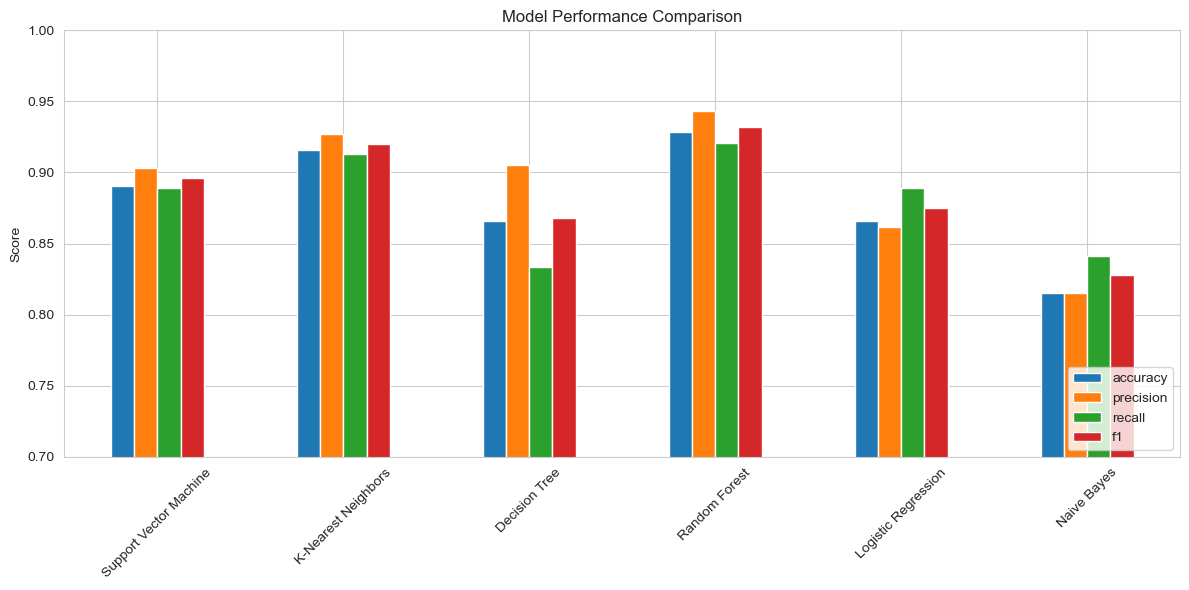

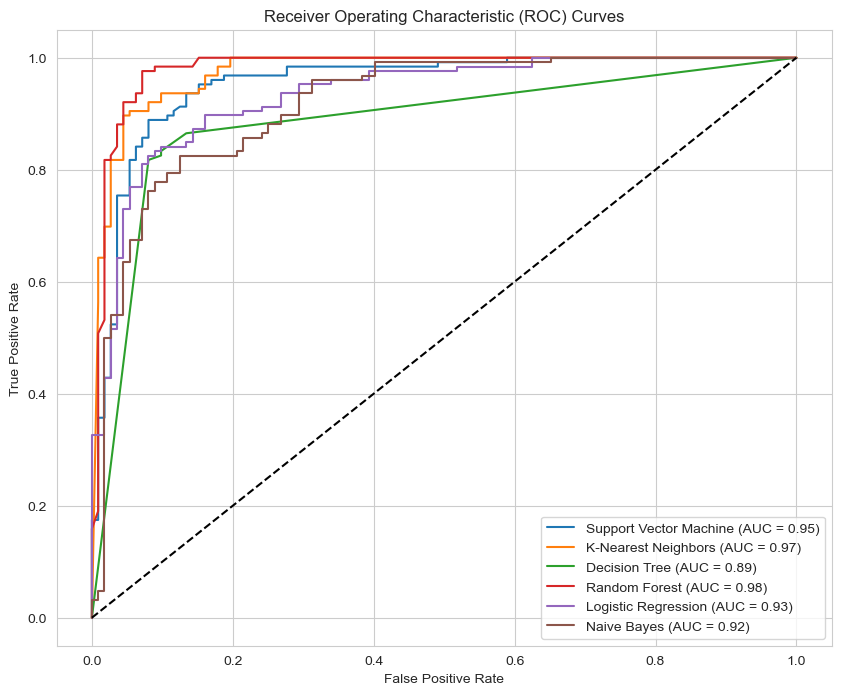

In [30]:
# ======================================================================
# 9. Results Comparison and Visualization
# ======================================================================
# Create a comparison DataFrame
comparison_df = pd.DataFrame.from_dict(results, orient='index')
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

print("\n=== MODEL COMPARISON ===")
print(comparison_df.sort_values(by='accuracy', ascending=False))

# Plot performance metrics
plt.figure(figsize=(12, 8))
comparison_df.drop('roc_auc', axis=1).plot(kind='bar', figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Plot ROC curves
plt.figure(figsize=(10, 8))
for model_name, result in results.items():
    if result['roc_auc'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['model'].predict_proba(X_test)[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()



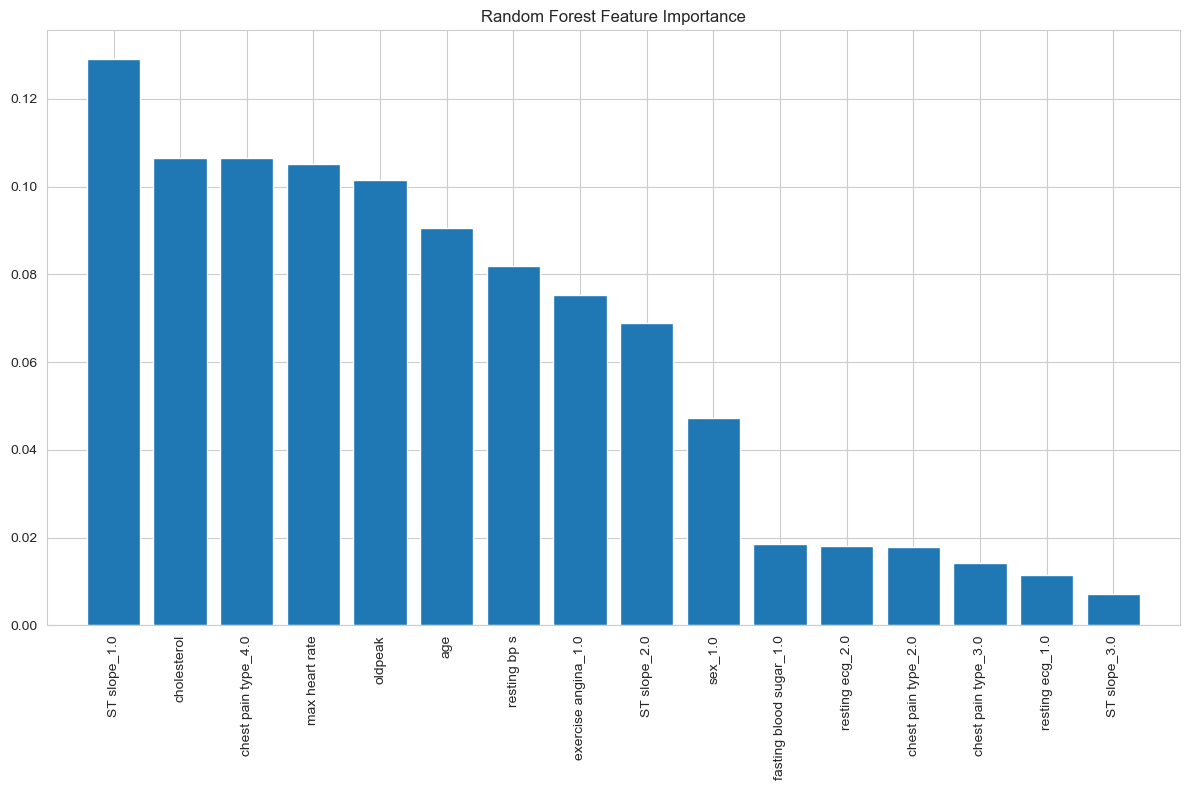

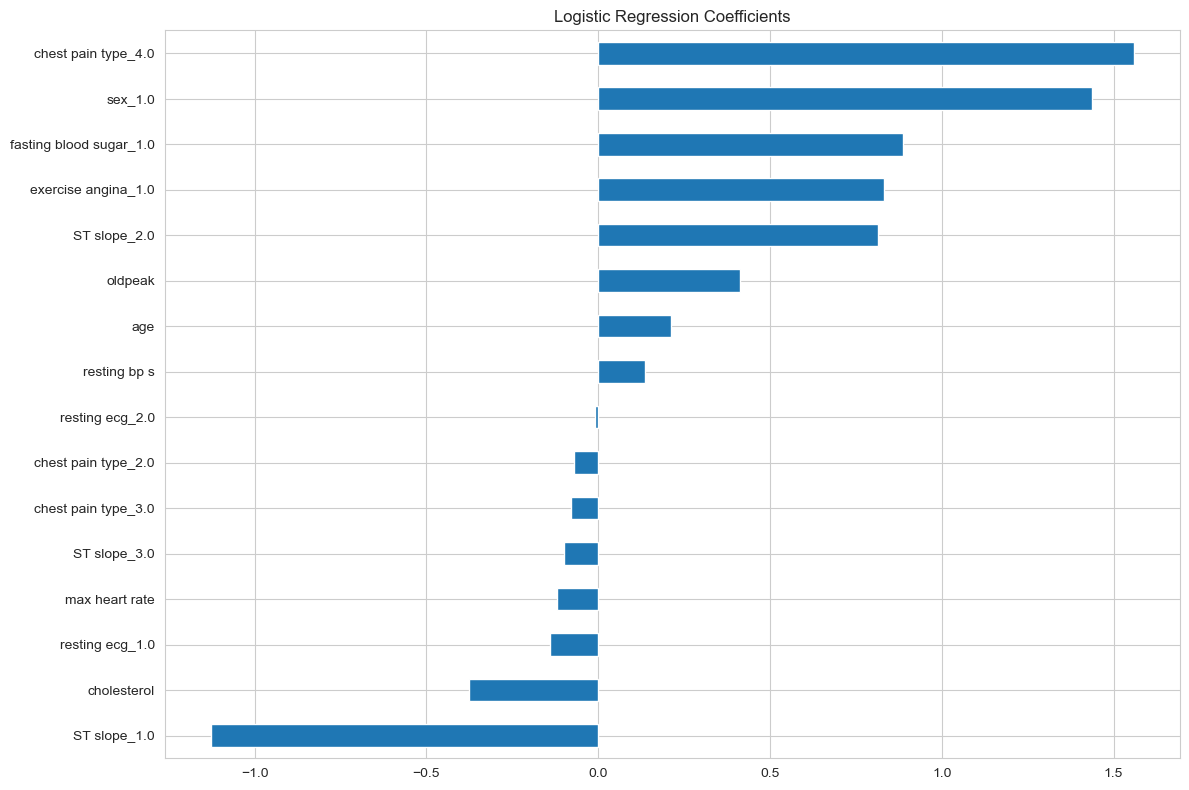

In [32]:
# ======================================================================
# 10. Feature Importance Analysis
# ======================================================================
# Get feature importance for tree-based models
if hasattr(results['Random Forest']['model'], 'feature_importances_'):
    plt.figure(figsize=(12, 8))
    importances = results['Random Forest']['model'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.title("Random Forest Feature Importance")
    plt.bar(range(X_train.shape[1]), importances[indices], align="center")
    plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
    plt.xlim([-1, X_train.shape[1]])
    plt.tight_layout()
    plt.show()

# Coefficients for logistic regression
if hasattr(results['Logistic Regression']['model'], 'coef_'):
    plt.figure(figsize=(12, 8))
    coefs = pd.Series(results['Logistic Regression']['model'].coef_[0], index=X_train.columns)
    coefs.sort_values().plot(kind='barh')
    plt.title("Logistic Regression Coefficients")
    plt.tight_layout()
    plt.show()